# Directional Dark Matter Detection Model

This project explores the directional detection of dark matter by modelling recoil energy spectra and directional event distributions in a xenon-based detector using Python.

## Overview

This project develops a Python-based simulation for directional dark matter detection, with a focus on recoil energy spectra, event-rate modelling, and sensitivity to physical assumptions. The current work provides an initial framework for exploring how directional information may improve signal interpretation.

This project focuses on:
- recoil energy spectra
- directional event rates
- sensitivity to modelling assumptions

## Modelling Approach

The simulation is based on the idea that dark matter particles interacting with detector nuclei produce recoil events with measurable energies and directions.

The model is used to:
- compute recoil energy distributions
- evaluate event rates across parameter ranges
- compare how changes in assumptions affect expected signals

# Imports and Parameter Setup

In [1]:
import numpy as np 
import matplotlib.pyplot as plt
import healpy as hp
from healpy.newvisufunc import projview, newprojplot
from tqdm.notebook import tqdm
import math as math
import matplotlib.cm as cm


import sys
sys.path.append('../funcs/phys_funcs')

In [2]:
s=0.9 #fm
a=0.52 #fm

ccm = 299792458*100 
ckm = 299792458/1000.0
convmchi = 1.783e-27 #GeV to kg
convsy = 365.25*3600*24

v_lab=220 #k/s
sigma=167 #km/S
v_esc=533 #km/s

rho=0.3*1e6 #keV cm^-3

mp=0.9315*1e6 #kev

v = [0,220,0] #km/s 
A = 132 #mass number of Xenon
m_chi = 100 #mass of the WIMP (dark matter particle) in GeV
sigmap = 1.0e-45 #cross section of a WIMP-proton scattering


m_p_keV = 0.9315*1e6 # proton mass in keV
c_cm = 2.99792458e8*100.0  # speed of light in cm/s
c_km = 2.99792458e8/1000.0 # speed of light in km/s
GeV_2_kg = 1.0e6*1.783e-33 # GeV to kg conversion
seconds2year = 365.25*3600*24


# Core Functions

 we are assuming to be the velocity of the lab in the galactic rest frame, so that the WIMP velocity is not time-dependent for now while it would be if we were looking at the velocity in the lab frame, as we would need to take into account the Earth's motion around the Sun, which would introduce an annual modulation in the directional rate as well, and the rotation of the Earth, which would introduce a daily modulation in the directional rate.

In [3]:
def j_1(x):
    
    return (np.sin(x)-x*np.cos(x))/(x**2) 

def Form(Er,A):
    
    mn=A*mp
    c=(1.23*(A**(1/3))-0.6) #fm
    r=np.sqrt(c**2+(7/3)*(np.pi**2)*(a**2)-5*(s**2)) #fm
    q=np.sqrt(2*mn*Er)*(1e-6*5.068) #because 1kev=1e-6*5.068 fm-1
    F = (3*j_1(q*r))*(np.exp(-(1/2)*(q*s)**2))/(q*r)
    F[q==0]=1

    return F

   
def MinimumWIMPSpeed(E_r,A,m_chi):

    # E_r = recoil energy in keVr
    # A = nucleus mass number
    # m_chi = WIMP mass in GeV
    m_N_keV = A*mp # nucleus mass in keV
    mu_N_keV = 1.0e6*m_chi*m_N_keV/(1.0e6*m_chi + m_N_keV) # reduced nucleus mass
    v_min = np.sqrt(1.0/(2*m_N_keV*E_r))*(m_N_keV*E_r/mu_N_keV)*ckm

    return v_min

from scipy.special import erf 	   

def MeanInverseSpeed(v_min,sig_v=167,v_esc=533,v_lab=220):

    sqrt=np.sqrt
    pi=np.pi
    exp=np.exp
    
    N_esc = erf(v_esc/(sqrt(2)*sig_v))\
            -sqrt(2.0/pi)*(v_esc/sig_v)*exp(-v_esc**2/(2*sig_v**2))
    
    # Define:
    v_0 = sig_v*sqrt(2.0)
    x = v_min/v_0
    z = v_esc/v_0
    y = v_lab/v_0
    
    # Set up conditional terms
    g = np.zeros_like(v_min)
    g[(x<abs(y-z))&(z<y)] = (1.0/(v_0*y))
    g2 = (1/(2*N_esc*v_0*y))*(erf(x+y)-erf(x-y)-(4/sqrt(pi))*y*exp(-z**2))
    g3 = (1/(2*N_esc*v_0*y))*(erf(z)-erf(x-y)-(2/sqrt(pi))*(y+z-x)*exp(-z**2))
    
    # Apply conditions
    g[(x<abs(y-z))&(z>y)] = g2[(x<abs(y-z))&(z>y)]
    g[(abs(y-z)<x)&(x<(y+z))] = g3[(abs(y-z)<x)&(x<(y+z))]
    g[(y+z)<x] = 0

    return g

    
def dRdE_SI(E_r,m_chi,sigma_p,A,gvmin_function,rho_0=0.3):
    '''
    * Spin independent differentual recoil rate that takes in recoil energy in 
    units of keVr and a proton cross section in units of cm^2 and outputs a rate
    in units of (ton year keVr)^-1
    
    * gvmin_function should be a function that takes in v_min in (km/s) and outputs
    g(v_min) in units of (km/s)^-1
    '''
    
    # DM-proton reduced mass (in units of keV)
    mu_p = 1e6*m_chi*mp/(1e6*m_chi + mp)
    
    # Rate constants (in units cm kg^-1 s^-2)
    R0 = (ccm**2)*((rho_0*1e6*A**2*sigma_p)/(2*m_chi*convmchi*mu_p**2)) 

    # Mean inverse speed
    v_min = MinimumWIMPSpeed(E_r,A,m_chi)
    g = gvmin_function(v_min)/(1000*100) # convert to cm^-1 s

    # Compute rate = (Rate amplitude * gmin * form factor)
    FF = Form(E_r,A)**2
    dR = R0*g*FF
    dR = dR*convsy*1000 # convert to (ton-year-keV)^-1
    return dR

In [4]:
def MinimumWIMPSpeed_2(E,m_chi,A):
    
    # E is the recoil energy vector, with components in x,y,z directions

    E_r = np.sqrt(E[:, 0]**2 + E[:, 1]**2 + E[:, 2]**2) # Recoil energy

    mn=mp*A
    mun=(m_chi*1e6*mn)/(m_chi*1e6+mn)

    return np.sqrt((mn*E_r)/(2*mun**2))*ckm

def RadonTransf(v,vmin,E): #enforces directional kinematics by projecting onto the recoil direction

    E_r = np.sqrt(E[:, 0]**2 + E[:, 1]**2 + E[:, 2]**2) # Recoil energy
    x = np.zeros(shape=np.shape(E))
    x[:, 0] = E[:, 0] / E_r # Recoil direction
    x[:, 1] = E[:, 1] / E_r
    x[:, 2] = E[:, 2] / E_r

    sigma=167 #km/Ss
    v_esc=544 #km/s

    mydot=np.dot(x,v)
    
    array_shape = np.shape(vmin)
    vesc = np.repeat(v_esc,array_shape)
        
    N_esc=erf(vesc/(math.sqrt(2)*sigma))-math.sqrt(2/math.pi)*vesc/sigma*np.exp(-(vesc**2)/(2*sigma**2))
       
    f=np.zeros_like(vmin)

    exponent = -abs(vmin+mydot)**2/(2*sigma**2)

    exp1=np.exp(exponent)
    exp2=np.exp(-((vesc)**2)/(2*sigma**2))
    den=N_esc*np.sqrt(2*np.pi*sigma**2)
    
    bool_cond1 = vmin + mydot < vesc
    bool_cond2 = vmin + mydot > vesc

    f[bool_cond1] = (exp1[bool_cond1] - exp2[bool_cond1]) / den[bool_cond1]
    f[bool_cond2] = 0

    f=f/(1000*100) #(s/cm)
    f=f*(ccm**2) #s cm-1 cm2 s-2 

    return f*convsy #cm/yr

def dRdEdO_SI(sigmap,E,A,m_chi,v,vmin): #standard spin-independent recoil spectrum

    rho=0.3*1e6 #keV cm^-3
    mp=0.9315*1e6 #kev
    
    E_r = np.sqrt(E[:, 0]**2 + E[:, 1]**2 + E[:, 2]**2) # Recoil energy
    
    F=Form(E_r,A)**2    

    mup=(m_chi*1e6*mp)/(m_chi*1e6+mp) #in kev

    R0=(rho*sigmap*(A**2))/((mup**2)*2*m_chi*convmchi*2*np.pi) #kev cm-3 kev-2 kg-1 cm2 = kev-1 cm-1 kg-1

    R1=R0*F

    RT = RadonTransf(v,vmin,E)
 
    dRdEdO = R1*RT*1000 #in kev-1 ton-1 yr-1

    return dRdEdO



In [5]:
def lab_recoil_vectors(E, A, m_chi, sigmap, nside=16, n=10, size=1000):
    #E: array of 3-vector, A: target mass number, m_chi: WIMP mass, sigmap: cross-section, 
    #nside=16: default HEALPix resolution, n=10: default number of recoil-energy bins, size=1000: default number of recoil events to randomly generate
    #This function takes a list of possible recoil direction-energy combinations, works out how likely each one is, and then randomly samples fake recoil events from that distribution.
    v_lab = np.array([0,220,0]) #km/s
    # this we are assuming to be the velocity of the lab in the galactic rest frame

    ### rate ###    

    Dl = np.zeros((n*12*nside**2))
    v_min = MinimumWIMPSpeed_2(E,m_chi,A)
    Dl = dRdEdO_SI(sigmap,E,A,m_chi,v_lab,v_min)#calculate rate

    if not np.any(Dl != 0):
        raise ValueError("Dl is entirely zeros.") #make sure it actually works
    #e.g if Er is too high, min speeds exceed esc velo, or if f(x) is broken
    
    ### prob generation ###

    p = Dl / np.sum(Dl) #find prob, normalises so all entried sum to 1, turns inot a probability distribution --> bigger bin = bigger dust over grid
    #this step lets you do monte carlo sampling
    p = p.astype('float64')
    #stores approx 16 decimal digits of precision --> avoids roundning erros or probabilities that dont sum up to excatly 1, also prevents small P's from beocming 0

    if np.any(np.isnan(p)):
        raise ValueError("p contains NaN values after normalization")
    
    ### reshuffling ###

    I = np.arange(0, len(Dl)) #wondering if this could be more?
    random_indices = np.random.choice(I, size=size, p=p) #randomise indices based on prob

    # Dl_new = Dl[rand]
    new_ind = I[random_indices]
    new_ind = new_ind.astype(int)

    ### find new recoil energy ###

    E_l = E[new_ind]
    E_norms_l = np.sqrt(E_l[:, 0]**2 + E_l[:, 1]**2 + E_l[:, 2]**2) #|E|=Er

    ### find correpsonding direction ###

    ql = np.array([E_l[:, 0], E_l[:, 1], E_l[:, 2]]) / E_norms_l
    #q1 = E/|E| bcs E=Er*q
    ql = ql.T
    #transposes the array from 3 rows and # events columns to one row per event and 3 columns (x,y,z)

    ### angular distributions ###

    costhetan = ql[:,0] #north?
    costhetaw = ql[:,1] #west?
    costhetaz = ql[:, 2] #z: Zenith = vector from head to atmosphere from lab?

    phin = np.mod(np.arctan2(ql[:, 1], ql[:, 2]), 2 * np.pi)
    phiw = np.mod(np.arctan2(ql[:, 2], ql[:, 0]), 2 * np.pi)
    phiz = np.mod(np.arctan2(ql[:, 1], ql[:, 0]), 2 * np.pi)

    return ql, E_norms_l, costhetan, costhetaw, costhetaz, phin, phiw, phiz

def vec_generator_energies(nside, n, Ermin, Ermax):

    npix   = hp.nside2npix(nside) #higher nside = finer angular resolution
    vecs   = np.array(hp.pix2vec(nside, np.arange(npix))).T  # (npix, 3)
    Ervals = np.linspace(Ermin, Ermax, n)                     # (n,)

    # outer product: for each pixel direction, scale by each energy
    # vecs[:, np.newaxis, :] is (npix, 1, 3)
    # Ervals[np.newaxis, :, np.newaxis] is (1, n, 1)
    E = (vecs[:, np.newaxis, :] * Ervals[np.newaxis, :, np.newaxis]).reshape(-1, 3)  # (npix*n, 3)
    #creates vectors in the form E=Er*q, it creates one 3-vector w directional and energy info

    return E

vecs = vec_generator_energies(nside=16, n=10, Ermin=0.1, Ermax=100) #Er in keV

ql, E_norms_l, costhetan, costhetaw, costhetaz, phin, phiw, phiz = lab_recoil_vectors(vecs, A, m_chi, sigmap)


# Example Simulations and Results

1. Directional WIMP recoil rate. 

This plot illustrates the anisotropic distribution of recoil events expected from WIMP interactions, with a clear directional peak aligned with the Earth's motion through the dark matter halo (towards Cygnus). The result highlights how directional information can enhance signal discrimination compared to non-directional detection methods.

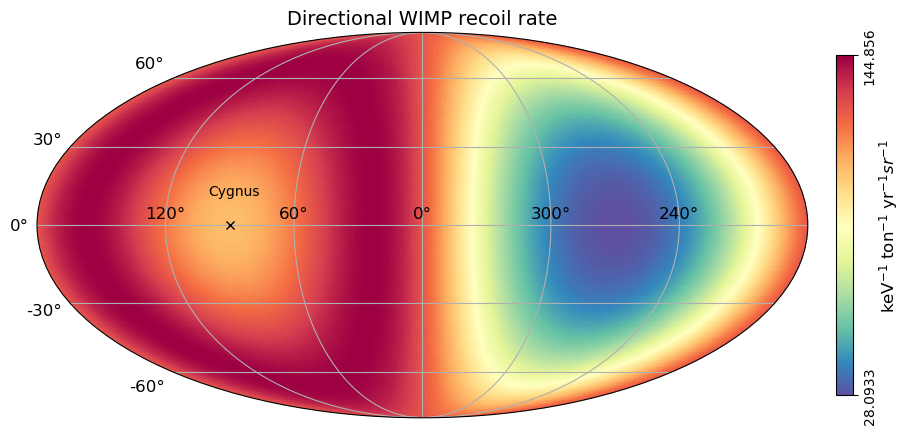

In [6]:

nside  = 64
n      = 100
Ermin, Ermax = 0.1, 10
v_lab = np.array([0, 220, 0])

# build recoil vectors: (npix*n, 3)
E = vec_generator_energies(nside, n, Ermin, Ermax)
npix = hp.nside2npix(nside)

vmin = MinimumWIMPSpeed_2(-E, m_chi, A) #why -E?
rate = dRdEdO_SI(sigmap, -E, A, m_chi, v_lab, vmin)  # (npix*n,)

# sum over energy bins for each pixel
Dwimp = rate.reshape(npix, n).sum(axis=1)

projview(
    Dwimp,
    coord=["G"],
    graticule=True,
    graticule_labels=True,
    unit=r"keV$^{-1}$ ton$^{-1}$ yr$^{-1} sr^{-1}$",
    cb_orientation="vertical",
    cmap='Spectral_r',
    projection_type="mollweide",
    title='Directional WIMP recoil rate'
)

plt.plot(-np.pi/2,0,'x',color='black')
plt.text(-np.pi/2-0.2,0.2,'Cygnus')

plt.show()

2. Creating a Probability Map of Recoil Directions.

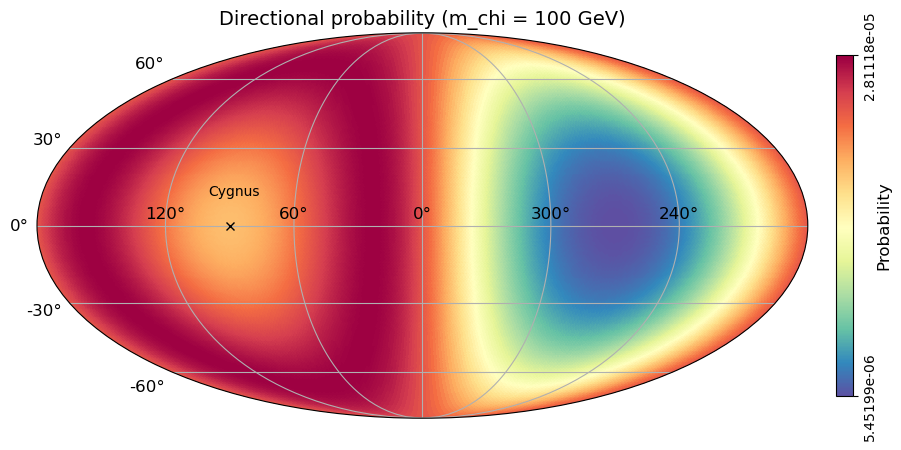

In [7]:
Dwimp = rate.reshape(npix, n).sum(axis=1)

m_chi = 100 #GeV

#Normalising
Dwimp_prob = Dwimp / np.sum(Dwimp)

projview(
    Dwimp_prob,
    coord=["G"],
    graticule=True,
    graticule_labels=True,
    unit="Probability",
    cb_orientation="vertical",
    cmap='Spectral_r',
    projection_type="mollweide",
    title=f"Directional probability (m_chi = {m_chi} GeV)"
)

plt.plot(-np.pi/2, 0, 'x', color='black')
plt.text(-np.pi/2 - 0.2, 0.2, 'Cygnus')

plt.show()

3. Velocity Sensitivity Analysis. 

Analysed sensitivity of the directional recoil rate to changes in the laboratory velocity by comparing a baseline configuration [0,220,0] with a pertubed case [30,220,20]. A tilted reference frame was used to compare the resulting distributions and identify regions of increased and suppressed event rates. The results demonstrate how variations in the velocity vector shift the anisotropic signal structure.

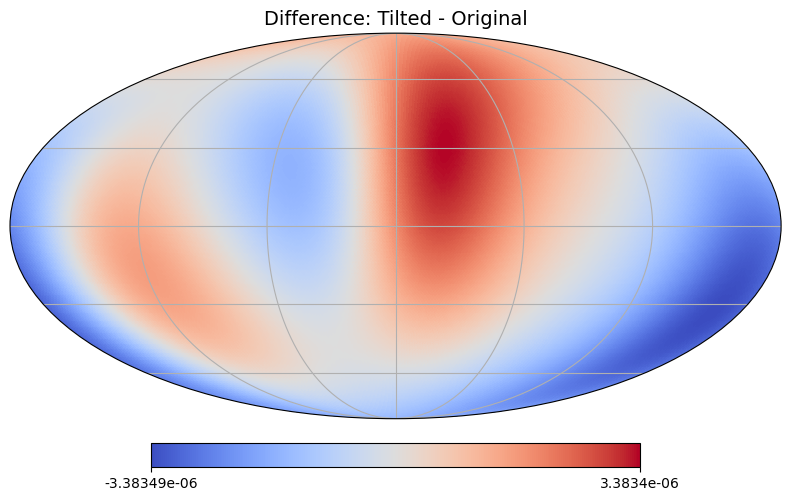

In [8]:
v_original = np.array([0, 220, 0])
v_new = 220 * np.array([30, 220, 20]) / np.linalg.norm([30, 220, 20])
Ervals = np.linspace(Ermin, Ermax, n) #sampling recoil energies

results = {}

for label, v_lab in {"original": v_original, "tilted": v_new}.items():
    vmin = MinimumWIMPSpeed_2(-E, m_chi, A)
    rate = dRdEdO_SI(sigmap, -E, A, m_chi, v_lab, vmin)
    rate_2d = rate.reshape(npix, n)

    Dwimp = np.trapezoid(rate_2d, x=Ervals, axis=1)
    Dwimp_prob = Dwimp / np.sum(Dwimp)

    results[label] = Dwimp_prob


diff = results["tilted"] - results["original"]

projview(
    diff,
    coord=["G"],
    graticule=True,
    cmap="coolwarm",
    projection_type="mollweide",
    title="Difference: Tilted - Original"
)

plt.show()